In [1]:
import numpy as np
import fitsio

des_expos = np.genfromtxt(
    "/home/vwetzell/gitrepos/highpm/data/all_desy6.csv",
    delimiter=",",
    names=True,
    dtype=None,
)

des_comps = fitsio.read(
    "/home/vwetzell/gitrepos/highpm/data/y6a1c.exposures.positions.fits", ext=1
)

In [2]:
from numpy.lib.recfunctions import join_by, rename_fields

des_expos = rename_fields(
    des_expos,
    {"EXPNUM": "expnum"},
)

des_all = join_by(
    "expnum",
    des_expos,
    des_comps,
    usemask=False,
    asrecarray=True,
    r1postfix="_expos",
    r2postfix="_comps",
)

des_all = des_all[(des_all["c"] <= 1) & (des_all["k"] < 7)]

In [3]:
des_g = des_all[des_all["BAND"] == "g"]
des_r = des_all[des_all["BAND"] == "r"]
des_i = des_all[des_all["BAND"] == "i"]
des_z = des_all[des_all["BAND"] == "z"]

In [4]:
print(des_r.dtype.names)

('expnum', 'PFW_ATTEMPT_ID', 'PATH', 'TDECDEG', 'TRADEG', 'BAND', 'EXPTIME', 'NITE', 'PROPID', 'T_EFF', 'PSF_FWHM', 'MJD_OBS', 'FLAG', 'cov', 'covwarn', 'dec', 'ecl_lat', 'ecl_lon', 'filter', 'mjd_mid', 'observatory', 'obs_ecl_lon', 'ra', 'band', 'm50', 'k', 'c', 'velocity')


In [5]:
zp = fitsio.read("/home/vwetzell/gitrepos/highpm/data/zeropoint1.fits", ext=1)

expnums, inv = np.unique(zp["EXPNUM"], return_inverse=True)
mag_zero = zp["MAG_ZERO"]
good = np.isfinite(mag_zero)
sum_mag = np.bincount(inv[good], weights=mag_zero[good])
cnt_mag = np.bincount(inv[good])
mean_zp = sum_mag / cnt_mag

zp_arr = np.empty(
    expnums.size,
    dtype=[("expnum", expnums.dtype), ("mean_zp", mean_zp.dtype)],
)
zp_arr["expnum"] = expnums
zp_arr["mean_zp"] = mean_zp


des_g_zp = join_by(
    "expnum",
    des_g,
    zp_arr,
    usemask=False,
    asrecarray=True,
    r1postfix="_des",
    r2postfix="_zp",
)

des_r_zp = join_by(
    "expnum",
    des_r,
    zp_arr,
    usemask=False,
    asrecarray=True,
    r1postfix="_des",
    r2postfix="_zp",
)

des_i_zp = join_by(
    "expnum",
    des_i,
    zp_arr,
    usemask=False,
    asrecarray=True,
    r1postfix="_des",
    r2postfix="_zp",
)

des_z_zp = join_by(
    "expnum",
    des_z,
    zp_arr,
    usemask=False,
    asrecarray=True,
    r1postfix="_des",
    r2postfix="_zp",
)

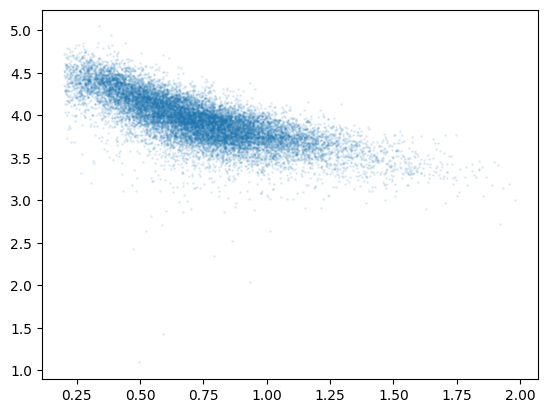

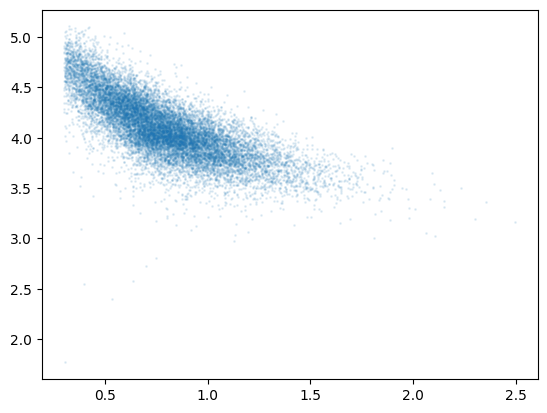

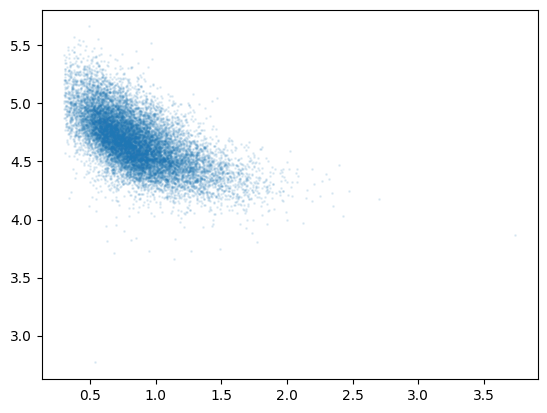

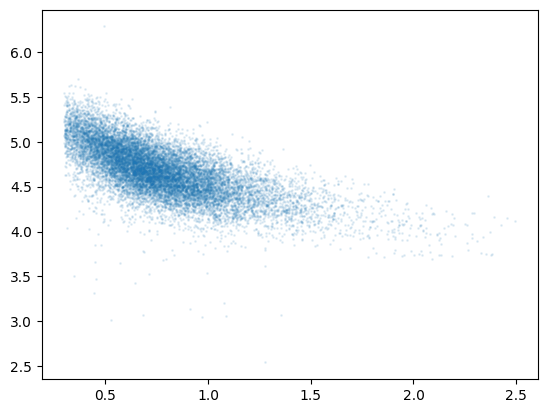

In [6]:
import matplotlib.pyplot as plt

for des_zp in [des_g_zp, des_r_zp, des_i_zp, des_z_zp]:
    plt.figure()
    plt.scatter(
        des_zp["T_EFF"],
        des_zp["k"],
        s=1,
        alpha=0.1,
    )
    # plt.ylim(1,6)
    plt.show()

1.2986906296806136
1.5648736619256254
1.0216364333895953
1.2827276466334172


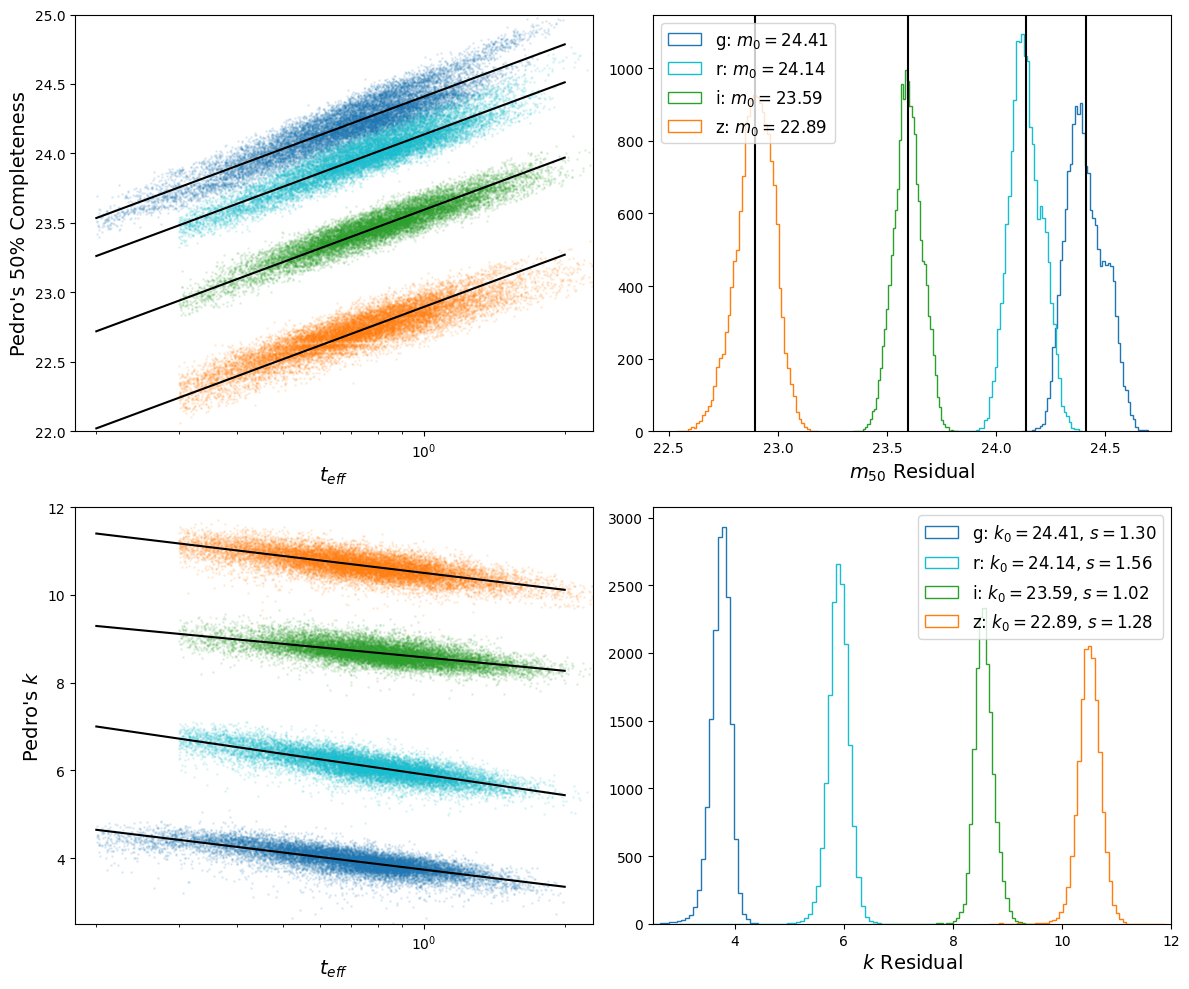

In [7]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].set_xscale("log")
ax[1, 0].set_xscale("log")


eta = 1.0

band_dict = {
    "g": {
        "cat": des_g_zp,
        "eta": 1.0,
        "b_dark": 22.23,
        "m0": 23.4,
        "color": "tab:blue",
    },
    "r": {
        "cat": des_r_zp,
        "eta": 1.0,
        "b_dark": 21.4,
        "m0": 23.1,
        "color": "tab:cyan",
    },
    "i": {
        "cat": des_i_zp,
        "eta": 1.0,
        "b_dark": 20.18,
        "m0": 22.5,
        "color": "tab:green",
    },
    "z": {
        "cat": des_z_zp,
        "eta": 1.0,
        "b_dark": 18.12,
        "m0": 21.8,
        "color": "tab:orange",
    },
}

z = np.linspace(0.2, 2, 100)
cnt = 0

for band, info in band_dict.items():
    des_zp = info["cat"]
    eta = info["eta"]
    b_dark = info["b_dark"]
    m0 = info["m0"]

    teff_obs = des_zp["T_EFF"]
    m50_obs = des_zp["m50"]
    k_obs = des_zp["k"]
    good = (
        np.isfinite(teff_obs)
        & np.isfinite(m50_obs)
        & np.isfinite(k_obs)
        & (teff_obs > 0)
    )
    teff_obs = teff_obs[good]
    m50_obs = m50_obs[good]
    k_obs = k_obs[good]

    # tau = eta**2 * (des_zp["PSF_FWHM"] / 0.9) ** -2 * (des_zp["mean_zp"] / b_dark) ** -1
    # tau = des_zp["T_EFF"]  # / des_zp["EXPTIME"]

    # m_lim = des_zp["m50"]  # - 2.5 * np.log10(10 / 3.5 / 1.0857)

    ax[0, 0].scatter(teff_obs, m50_obs, s=1, alpha=0.1, color=info["color"])

    # Joint fit: optimize (m0, a, b) using both m50(teff) and k(m50) together.
    # curve_fit expects a 1D residual vector, so we concatenate the two targets.
    def teff2m50k_concat(teff, m0, k0, s0):
        m50 = m0 + 1.25 * np.log10(teff)
        k = k0 - s0 * np.log10(teff)
        return np.concatenate([m50, k])

    ydata = np.concatenate([m50_obs, k_obs])
    fit = curve_fit(teff2m50k_concat, teff_obs, ydata, p0=[m0, 0.0, 0.0])
    m0_fit, k0_fit, s_fit = fit[0]

    def m50_from_teff(teff, m0):
        return m0 + 1.25 * np.log10(teff)

    ax[0, 0].plot(
        z,
        m50_from_teff(z, m0_fit),
        color="k",
    )

    resid = m50_obs - m50_from_teff(teff_obs, m0_fit)

    # plt.figure()
    # plt.scatter(teff_obs, resid, s=1, alpha=0.3)
    # plt.show()

    # print(np.corrcoef(resid, k_obs)[0, 1])

    print(s_fit)

    ax[0, 1].hist(
        resid + m0_fit,
        bins=50,
        histtype="step",
        label=band + r": $m_0=${:0.2f}".format(m0_fit),
        color=info["color"],
    )
    ax[0, 1].axvline(m0_fit, color="k")

    ax[1, 0].scatter(teff_obs, k_obs + cnt, s=1, alpha=0.1, color=info["color"])
    ax[1, 0].plot(
        z,
        k0_fit - s_fit * np.log10(z) + cnt,
        color="k",
    )
    # print(k0_fit)

    k_resid = k_obs - (k0_fit - s_fit * np.log10(teff_obs)) + cnt

    ax[1, 1].hist(
        k_resid + k0_fit,
        bins=50,
        histtype="step",
        label=band + r": $k_0=${:0.2f}, $s=${:0.2f}".format(m0_fit, s_fit),
        color=info["color"],
    )

    cnt += 2

# ax[0].legend(fontsize=12)
ax[0, 1].legend(fontsize=12, loc="upper left")
ax[1, 1].legend(fontsize=12)
ax[0, 0].set_xlim(0.18, 2.3)
ax[1, 0].set_ylim(2.5, 12.0)
ax[1, 1].set_xlim(2.5, 12.0)
ax[1, 0].set_xlim(0.18, 2.3)
ax[0, 0].set_ylim(22.0, 25.0)
# ax[1, 1].set_xlim(22.5, 25.0)
ax[0, 0].set_xlabel(r"$t_{eff}$", fontsize=14)
ax[0, 0].set_ylabel(
    "Pedro's 50% Completeness",
    fontsize=14,
)
ax[0, 1].set_xlabel(r"$m_{50}$ Residual", fontsize=14)
ax[1, 0].set_xlabel(r"$t_{eff}$", fontsize=14)
ax[1, 0].set_ylabel(r"Pedro's $k$", fontsize=14)
ax[1, 1].set_xlabel(r"$k$ Residual",fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
import healpy as hp

nside = 128

gaia_map = hp.read_map(
    "/home/vwetzell/Downloads/gaia_stellar_density_G21_equ_n128_v0.fits"
)

gaia_map = hp.ud_grade(gaia_map, nside)


# Average c per band in healpix pixels, to see if there are spatial patterns in the completeness parameter c.

temp_des_comps = des_all[des_all["band"] == "r"]

c_pixels = hp.ang2pix(
    nside, np.radians(90 - temp_des_comps["dec"]), np.radians(temp_des_comps["ra"])
)

c_map = np.zeros(hp.nside2npix(nside), dtype=np.float32)

for pix in range(hp.nside2npix(nside)):
    c_map[pix] = np.nanmedian(temp_des_comps["c"][c_pixels == pix])


# mask = np.isnan(c_map) | (c_map == 0)

# c_map[mask] = 0.0

# des_pixels = np.argwhere(np.isfinite(c_map)).flatten()

# gaia_map[~np.isfinite(c_map)] = np.nan


# c_map[mask] = np.nan
# gaia_map[mask] = np.nan

# gaia_map = np.clip(
#     gaia_map,
#     np.nanpercentile(gaia_map, 1),
#     np.nanpercentile(gaia_map, 99),
# )

# c_map = np.clip(
#     c_map,
#     np.nanpercentile(c_map, 1),
#     np.nanpercentile(c_map, 99),
# )


/home/vwetzell/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [9]:
# import numpy as np
# import healpy as hp
# from scipy.special import legendre


# def tophat_window(lmax, theta0_rad):
#     """
#     Compute the tophat window function W_ell for ell = 0..lmax.
#     theta0_rad: tophat radius in radians
#     """
#     cos_theta0 = np.cos(theta0_rad)
#     ells = np.arange(lmax + 1)

#     W = np.zeros(lmax + 1)
#     W[0] = (1.0 - cos_theta0) / 2.0

#     for ell in range(1, lmax + 1):
#         # Using the recurrence relation with Legendre polynomials
#         P_prev = legendre(ell - 1)(cos_theta0)
#         P_next = legendre(ell + 1)(cos_theta0)
#         W[ell] = (P_prev - P_next) / (2.0 * (2 * ell + 1))

#     return W / W[0]  # Normalize so that W_0 = 1


# def smooth_map_tophat(hmap, theta0_deg, lmax=None):
#     """
#     Smooth a HEALPix map with a tophat of radius theta0_deg degrees.
#     """
#     nside = hp.get_nside(hmap)
#     if lmax is None:
#         lmax = 3 * nside - 1

#     theta0_rad = np.radians(theta0_deg)

#     # 1. Forward transform: map -> alm
#     alm = hp.map2alm(hmap, lmax=lmax)

#     # 2. Build the window function
#     W = tophat_window(lmax, theta0_rad)

#     # 3. Apply window in harmonic space
#     alm_smoothed = hp.almxfl(alm, W)

#     # 4. Inverse transform: alm -> map
#     smoothed_map = hp.alm2map(alm_smoothed, nside=nside, lmax=lmax)

#     return smoothed_map


# c_map[np.isnan(c_map)] = np.mean(c_map[~np.isnan(c_map)])

# c_map_smooth = smooth_map_tophat(c_map, theta0_deg=1.1)

# c_map_smooth[mask] = np.nan


# gaia_map = np.clip(
#     gaia_map,
#     np.nanpercentile(gaia_map, 1),
#     np.nanpercentile(gaia_map, 99),
# )

# c_map_smooth_clipped = np.clip(
#     c_map_smooth,
#     np.nanpercentile(c_map_smooth, 1),
#     np.nanpercentile(c_map_smooth, 99),
# )



# hp.mollview(gaia_map, title="Gaia Stellar Density", unit=r"$stars/deg^2$")
# plt.show()

# hp.mollview(
#     c_map_smooth_clipped,
#     title="r-Band Mean Max Completeness Parameter c (Smoothed)",
#     unit="c",
#     cmap="viridis_r",
#     # min=0.85,
#     # max=0.95,
# )
# plt.show()

In [10]:
def pointings_to_healpix_weighted_median(
    ra, dec, values, nside, fov_radius_deg=1.1, oversample=4
):
    """
    Parameters
    ----------
    oversample : factor by which to increase nside for sub-pixel area estimation.
                 Higher values give more accurate weights at the cost of speed.
    """
    ra = np.asarray(ra)
    dec = np.asarray(dec)
    values = np.asarray(values)

    npix = hp.nside2npix(nside)
    pixel_values = [[] for _ in range(npix)]
    pixel_weights = [[] for _ in range(npix)]

    fov_radius_rad = np.radians(fov_radius_deg)
    nside_fine = nside * oversample
    # Number of fine pixels per coarse pixel
    n_subpix = oversample**2

    for i in range(len(ra)):
        theta = np.radians(90.0 - dec[i])
        phi = np.radians(ra[i])
        vec = hp.ang2vec(theta, phi)

        # Coarse pixels intersecting the disc
        coarse_pixels = hp.query_disc(nside, vec, fov_radius_rad, inclusive=True)

        # Fine pixels fully inside the disc (no need for inclusive here)
        fine_pixels_in_disc = hp.query_disc(
            nside_fine, vec, fov_radius_rad, inclusive=False
        )
        # Map fine pixels to their parent coarse pixel
        fine_to_coarse = hp.ud_grade(
            np.arange(hp.nside2npix(nside)),  # coarse identity map
            nside_out=nside_fine,
            order_in="RING",
            order_out="RING",
        )
        # Count how many fine pixels within the disc belong to each coarse pixel
        coarse_hit_counts = np.bincount(
            fine_to_coarse[fine_pixels_in_disc], minlength=npix
        )

        for p in coarse_pixels:
            weight = coarse_hit_counts[p] / n_subpix  # fraction of pixel covered
            if weight > 0:
                pixel_values[p].append(values[i])
                pixel_weights[p].append(weight)

    hmap = np.full(npix, np.nan)
    for p in range(npix):
        if pixel_values[p]:
            hmap[p] = weighted_median(
                np.array(pixel_values[p]), np.array(pixel_weights[p])
            )

    return hmap


def weighted_median(values, weights):
    """Weighted median: value at which cumulative weight crosses 0.5."""
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) / np.sum(weights)
    return values[np.searchsorted(cumulative, 0.5)]


hmap = pointings_to_healpix_weighted_median(
    ra=temp_des_comps["ra"],
    dec=temp_des_comps["dec"],
    values=temp_des_comps["c"],
    nside=nside,
    fov_radius_deg=1.1,
)

hmap_clipped = np.clip(
    hmap,
    np.nanpercentile(hmap, 1),
    np.nanpercentile(hmap, 99),
)


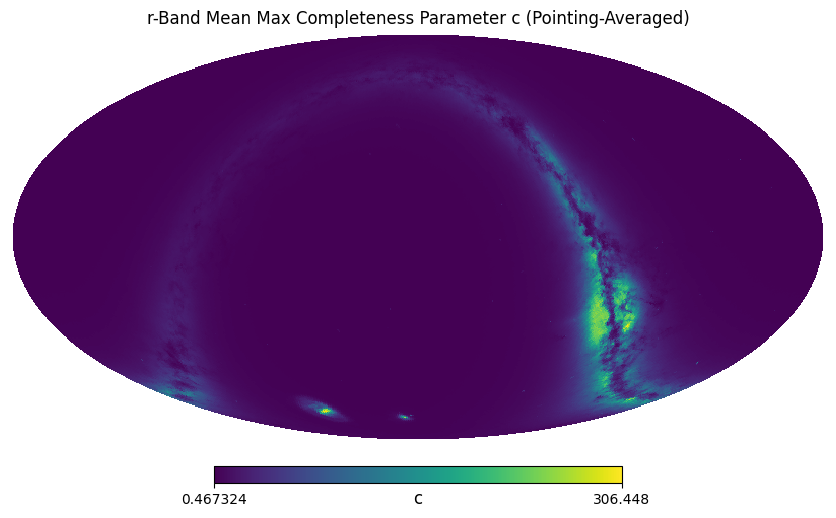

In [11]:

hp.mollview(
    gaia_map,
    title="r-Band Mean Max Completeness Parameter c (Pointing-Averaged)",
    unit="c",
    cmap="viridis",
    # min=0.85,
)
plt.show()

des_mask = np.isfinite(hmap_clipped)

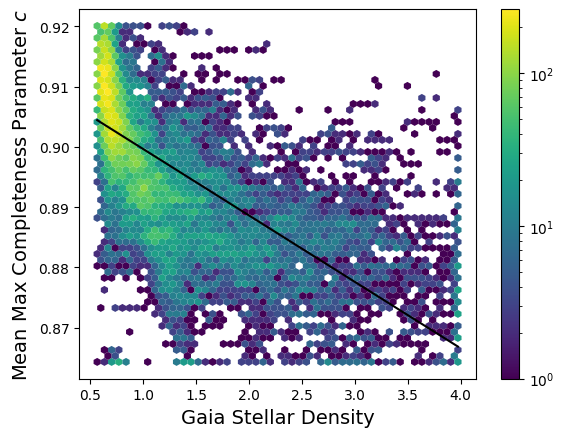

In [12]:
from matplotlib.colors import LogNorm

from scipy.optimize import curve_fit

gaia_map_clipped = np.clip(
    gaia_map,
    np.nanpercentile(gaia_map[des_mask], 1),
    np.nanpercentile(gaia_map[des_mask], 99),
)


popt, pcov = curve_fit(
    lambda x, a, b: a * x + b,
    gaia_map_clipped[des_mask],
    hmap_clipped[des_mask] - np.mean(hmap_clipped[des_mask]),
)

x = np.linspace(
    np.nanmin(gaia_map_clipped[des_mask]), np.nanmax(gaia_map_clipped[des_mask]), 100
)

plt.figure()
plt.plot(
    x,
    popt[0] * x + popt[1] + np.mean(hmap_clipped[des_mask]),
    color="k",
    label="Linear Fit",
)
plt.hexbin(
    gaia_map_clipped[des_mask],
    hmap_clipped[des_mask],
    # extent=(0.5, 3., 0.85, 0.95),
    gridsize=50,
    edgecolors="none",
    norm=LogNorm(),
    # xscale="log",
    # yscale="log",
    mincnt=1,
)
plt.colorbar()
plt.xlabel(r"Gaia Stellar Density", fontsize=14)
plt.ylabel(r"Mean Max Completeness Parameter $c$", fontsize=14)

# plt.xscale("log")
# plt.ylim(0.7, 0.95)
# plt.xlim(0.5, 1.5)
plt.show()

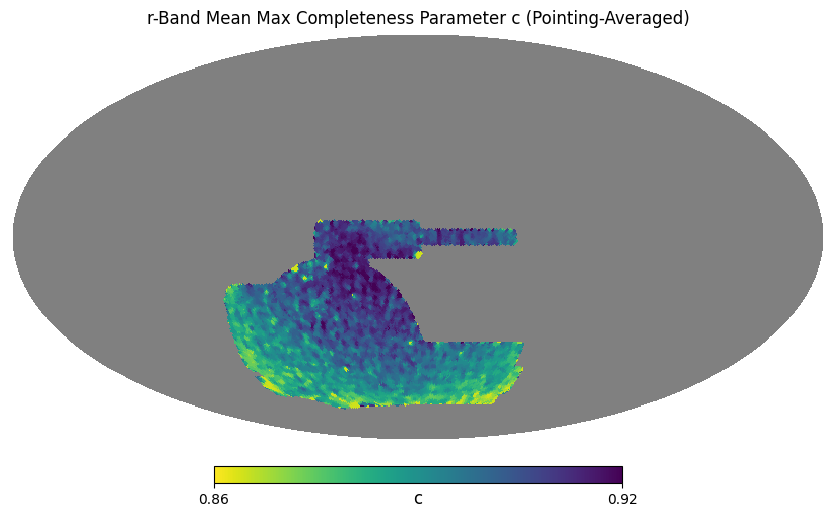

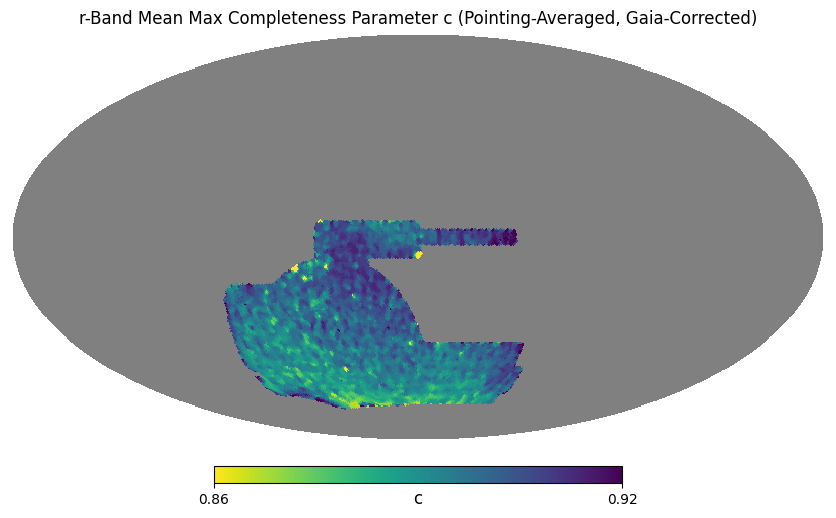

In [13]:
# from matplotlib.colors import LogNorm
hp.mollview(
    hmap_clipped,
    unit="c",
    cmap="viridis_r",
    min=0.86,
    max=0.92,
    title="r-Band Mean Max Completeness Parameter c (Pointing-Averaged)",
)
plt.show()

hp.mollview(
    hmap_clipped - (popt[0] * gaia_map_clipped + popt[1]),
    unit="c",
    cmap="viridis_r",
    min=0.86,
    max=0.92,
    title="r-Band Mean Max Completeness Parameter c (Pointing-Averaged, Gaia-Corrected)",
)
plt.show()

In [14]:
des_all_zp = join_by(
    "expnum",
    des_all,
    zp_arr,
    usemask=False,
    asrecarray=True,
    r1postfix="_des",
    r2postfix="_zp",
)

des_all_zp = des_all_zp[(des_all_zp["mean_zp"] > 0) & (des_all_zp["mean_zp"] < 33)]

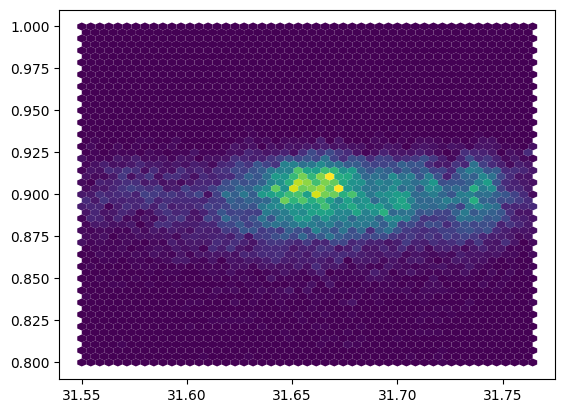

In [15]:
temp_des_all_zp = des_all_zp[(des_all_zp["BAND"] == "r")]

plt.figure()
plt.hexbin(
    temp_des_all_zp["mean_zp"],
    temp_des_all_zp["c"],
    gridsize=50,
    edgecolors="none",
    extent=(
        31.55,
        np.percentile(temp_des_all_zp["mean_zp"], 99),
        0.8,
        1.0,
    ),
)
plt.show()

In [16]:
des_all_zp.dtype.names

('expnum',
 'PFW_ATTEMPT_ID',
 'PATH',
 'TDECDEG',
 'TRADEG',
 'BAND',
 'EXPTIME',
 'NITE',
 'PROPID',
 'T_EFF',
 'PSF_FWHM',
 'MJD_OBS',
 'FLAG',
 'cov',
 'covwarn',
 'dec',
 'ecl_lat',
 'ecl_lon',
 'filter',
 'mjd_mid',
 'observatory',
 'obs_ecl_lon',
 'ra',
 'band',
 'm50',
 'k',
 'c',
 'velocity',
 'mean_zp')